# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zoye-J/FlyRank--MachineLearning/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [14]:
from google.colab import userdata
import os
import pandas as pd
import numpy as np
import duckdb
import json
import matplotlib.pyplot as plt

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute("CREATE SECRET hf (TYPE huggingface, PROVIDER credential_chain);")

FACT_MAR = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"
FACT_APR = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet"
FACT_MAY = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-05/*.parquet"
DIM_CONTENT = "hf://datasets/FlyRank/internship-warehouse/dim_content.parquet"

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Connected.")

Connected.


## 1. Ranked actions + reason codes

The queue is the Week-4 baseline score, frozen. One row per page; ranked descending by 'baseline_score = visible × low_ctr × impressions_30d'.

Action labels the queue can emit:

-  For 'review_ctr' with reason code 'visible_lowctr', human rewrite title/meta for the top-impression pages whose CTR sits below their position tier's median. Highest priority = most exposure, most recoverable. Confidence is high when impressions ≥ 1,000

- 'review_staleness' with reason code 'stale_visible', Refresh the page's facts, examples, and dates (small bucket on this release). Confidence medium.
- 'review_intent' with reason code 'stale_visible_lowctr`, Full content review for intent alignment (rare on this release — 0 rows).
- 'no_action' with 'not_flagged',  No queue entry and page is below the visibility floor or CTR is already at/above tier.

Reason codes are the trust anchor. A human reading row 1 of the queue sees "80,821 impressions, CTR 0.04%, position 1.5, tier median ≈ 0.27%" and knows why it is there.

Cost/value thinking:
- Cost of a wrong flag: ~2–4 editor hours on a page that was fine.
- Cost of a miss: a page with 80K impressions and 0.04% CTR stays that way for another quarter — a large, measurable loss.
- This asymmetry (misses are expensive, false positives are cheap) is what justifies a wide top-of-queue and a conservative action floor.

In [15]:
# Rebuilding the frozen queue from March 2026
QUEUE_Q = f"""
WITH perf AS (
  SELECT
    content_hash_id,
    ANY_VALUE(client_hash_id)         AS client_hash_id,
    SUM(gsc_impressions)              AS impressions_30d,
    SUM(gsc_clicks)                   AS clicks_30d,
    AVG(NULLIF(gsc_avg_position, 0))  AS avg_position_30d
  FROM '{FACT_MAR}'
  GROUP BY content_hash_id
),
future AS (
  SELECT content_hash_id, SUM(gsc_impressions) AS imp_apr_may
  FROM (
    SELECT content_hash_id, gsc_impressions FROM '{FACT_APR}'
    UNION ALL
    SELECT content_hash_id, gsc_impressions FROM '{FACT_MAY}'
  )
  GROUP BY content_hash_id
)
SELECT
  p.content_hash_id,
  p.client_hash_id,
  p.impressions_30d,
  p.clicks_30d,
  p.avg_position_30d,
  d.content_type,
  d.main_intent,
  DATE_DIFF('day', d.content_updated_date, DATE '2026-03-31') AS days_since_update,
  f.imp_apr_may
FROM perf p
LEFT JOIN '{DIM_CONTENT}' d ON p.content_hash_id = d.content_hash_id
LEFT JOIN future f ON p.content_hash_id = f.content_hash_id
WHERE p.impressions_30d IS NOT NULL AND p.impressions_30d > 0
"""
df = con.execute(QUEUE_Q).df()

df["ctr_30d"] = np.where(df["impressions_30d"] > 0,
                         100.0 * df["clicks_30d"] / df["impressions_30d"],
                         np.nan)
df["position_tier"] = pd.cut(
    df["avg_position_30d"],
    bins=[0, 3, 10, 20, 50, 1e9],
    labels=["top_3", "page_1", "page_2", "page_3_5", "deep"],
)
tier_medians = df.groupby("position_tier", observed=True)["ctr_30d"].median()
df["tier_median_ctr"] = df["position_tier"].map(tier_medians)

df["stale"]     = ((df["days_since_update"] >= 180) & (df["days_since_update"] >= 0)).astype(int)
df["visible"]   = (df["impressions_30d"] >= 500).astype(int)
df["low_ctr"]   = (df["ctr_30d"] < df["tier_median_ctr"]).astype(int)
df["baseline_score"] = (df["visible"] * df["low_ctr"] * df["impressions_30d"]).fillna(0)

def reason_code(r):
    if r["stale"] and r["visible"] and r["low_ctr"]: return "stale_visible_lowctr"
    if r["stale"] and r["visible"]:                  return "stale_visible"
    if r["stale"]:                                   return "stale_only"
    if r["visible"] and r["low_ctr"]:                return "visible_lowctr"
    return "not_flagged"

def action_label(r):
    if r["reason_code"] == "stale_visible_lowctr": return "review_intent"
    if r["reason_code"] == "visible_lowctr":       return "review_ctr"
    if r["reason_code"] == "stale_visible":        return "review_staleness"
    return "no_action"

df["reason_code"]  = df.apply(reason_code, axis=1)
df["action_label"] = df.apply(action_label, axis=1)

df["is_declining_future"] = np.where(
    df["imp_apr_may"].isna() | (df["impressions_30d"] == 0),
    np.nan,
    (df["imp_apr_may"] < 0.8 * df["impressions_30d"]).astype(float),
)

df = df.sort_values(["baseline_score", "impressions_30d"],
                    ascending=[False, False]).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)

print(f"Queue rows: {len(df):,}")
print(f"Actions emitted:")
print(df["action_label"].value_counts().to_string())
print()
print("Top 10:")
print(df[["rank", "action_label", "reason_code", "baseline_score",
          "impressions_30d", "ctr_30d", "avg_position_30d"]].head(10).to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Queue rows: 176,738
Actions emitted:
action_label
no_action           175364
review_ctr            1368
review_staleness         6

Top 10:
 rank action_label    reason_code  baseline_score  impressions_30d  ctr_30d  avg_position_30d
    1   review_ctr visible_lowctr         80821.0          80821.0 0.043306          1.488604
    2   review_ctr visible_lowctr         70398.0          70398.0 0.059661          1.556258
    3   review_ctr visible_lowctr         65304.0          65304.0 0.093409          1.541702
    4   review_ctr visible_lowctr         60172.0          60172.0 0.029914          2.261303
    5   review_ctr visible_lowctr         44217.0          44217.0 0.090463          2.397902
    6   review_ctr visible_lowctr         43135.0          43135.0 0.064912          2.502348
    7   review_ctr visible_lowctr         38000.0          38000.0 0.002632          2.740744
    8   review_ctr visible_lowctr         35083.0          35083.0 0.059858          2.838985
    9   review

## 2. Intended use and limits

Intended use: A weekly editorial review meeting. The content lead opens the queue, filters to 'review_ctr', and assigns the top 20–50 rows across the team. Each row's reason code tells the editor what to look at first. This is a triage aid, not a publishing system.

Who uses it: a content editor or SEO lead. The queue does not automate edits, does not publish, and does not make ranking decisions.

Where it stops being valid:

- Client overlap. The queue is built on a March 2026 slice. On a different month, tier medians shift and the score should be recomputed.
- The 'review_ctr' action assumes the tier median is stable. For sparse position tiers ( deep, n small), the median is noisy and a below-median flag is weak evidence.
- It cannot see the page. CTR below tier median is a symptom. The cause may be title, meta, intent mismatch, or SERP competition. The queue does not tell you which.
- It excludes staleness as a filter because 'content_updated_date' is a sync artifact on this release (84.2% of rows have negative 'days_since_update'). Staleness can only boost a signal that already fired.


In [16]:
# Intended-use boundary: what the queue can and cannot tell a reviewer.
print("Queue slice: 2026-03 prior window; label window 2026-04/05.")
print(f"Pages in queue: {len(df):,}")
print(f"Flagged (score > 0): {(df['baseline_score'] > 0).sum():,}")
print()
print("Top action: review_ctr, requires human snippet/SEO rewrite")
print("No action is ever taken by the notebook; the queue is decision-support only.")
print()
# Confirming no security-shaped field is a queue input
security_check = {"baseline_score", "reason_code", "action_label"} & \
                 {"is_declining_future", "imp_apr_may"}
print(f"Queue outputs overlap label sources: {security_check if security_check else 'NONE'}")
print("No malicious-content signal exists in this dataset or queue.")

Queue slice: 2026-03 prior window; label window 2026-04/05.
Pages in queue: 176,738
Flagged (score > 0): 1,368

Top action: review_ctr, requires human snippet/SEO rewrite
No action is ever taken by the notebook; the queue is decision-support only.

Queue outputs overlap label sources: NONE
No malicious-content signal exists in this dataset or queue.


## 3. Human review + the no-go list


What a person must check before acting:

1. Open the page and read it. The queue cannot see content. A 'review_ctr' flag on a page whose content genuinely does not match the query is a rewrite, not a metadata fix.
2. Check the SERP for the target query. A low CTR with a strong ranking may mean the SERP is dominated by features (AI Overviews, product carousels), not a weak title.
3. Confirm the page is still live and intended. A page scheduled for retirement does not need a CTR fix.
4. Sanity-check the tier median on the row. If the page sits in a sparse tier, treat the low-CTR flag as weak evidence.

What should never be automated:

- Publishing. No model in this workflow writes or publishes content.
- Redirects, canonical changes, or noindex decisions.
- Anything touching user privacy, tracking, or access. Not in scope, not in the queue.
- Flags against a named client or URL as malicious. The queue has no security signal and cannot support that claim.
- Reordering the queue without retraining. Frozen at Week 4 by design.

In [17]:
# Prove the queue's top rows meet the "human review first" criterion, top rows should have high impressions (big potential upside) and be a real page.
top20 = df.head(20)
print("Top-20 sanity: every row must have impressions >= 500 (the visibility floor).")
print(f"  Min impressions in top-20: {int(top20['impressions_30d'].min()):,}")
print(f"  Min impressions across all flagged rows: "
      f"{int(df.loc[df['baseline_score'] > 0, 'impressions_30d'].min()):,}")


Top-20 sanity: every row must have impressions >= 500 (the visibility floor).
  Min impressions in top-20: 27,538
  Min impressions across all flagged rows: 500


## 4. Monitoring / retrain triggers

The queue is a rule, not a model. It does not need retraining, but it does need revalidation when its assumptions stop holding.

Triggers to re-run the analysis:

1. Tier medians shift by more than ~20%. Recompute monthly. If a position tier's median CTR moves materially, the 'low_ctr' flag on that tier is no longer comparable.
2. Precision@50 drops below the base rate. If the top-50 precision falls under ~0.28 on a fresh month's future window, the rule has lost its lift.
3. The 'content_updated_date' column is fixed upstream. If the sync artifact is resolved and the field becomes a real last-edit date, the staleness signal can be re-promoted from booster to gate and the reason-code distribution should be re-measured.
4. Action mix collapses to one code. If 'review_ctr' becomes 100% of the flags for months, the rule is not discriminating; re-examine tiers and thresholds.
5. The dataset's label definition changes. If 'imp_apr_may' or 'impressions_30d' semantics shift, the queue's lift is no longer comparable to this run.



In [20]:
# Recording the baseline's standing metrics — the numbers to watch against future months.
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.nanmean(np.asarray(labels)[order[:k]]))

eval_df = df.dropna(subset=["is_declining_future"])
y = eval_df["is_declining_future"].values

metrics = {
    "slice": "2026-03 prior window; label = 2026-04/05 future window",
    "queue_rows": int(len(df)),
    "flagged_rows": int((df["baseline_score"] > 0).sum()),
    "precision_at_20": round(precision_at_k(eval_df["baseline_score"], y, 20), 4),
    "precision_at_50": round(precision_at_k(eval_df["baseline_score"], y, 50), 4),
    "base_rate": round(float(np.nanmean(y)), 4),
    "reason_code_counts": df["reason_code"].value_counts().to_dict(),
    "action_label_counts": df["action_label"].value_counts().to_dict(),
}

with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print("Baseline standing metrics (to monitor against future months):")
for k, v in metrics.items():
    print(f"  {k}: {v}")

Baseline standing metrics (to monitor against future months):
  slice: 2026-03 prior window; label = 2026-04/05 future window
  queue_rows: 176738
  flagged_rows: 1368
  precision_at_20: 0.6
  precision_at_50: 0.56
  base_rate: 0.283
  reason_code_counts: {'not_flagged': 175109, 'visible_lowctr': 1368, 'stale_only': 255, 'stale_visible': 6}
  action_label_counts: {'no_action': 175364, 'review_ctr': 1368, 'review_staleness': 6}


## 5. Exports for the paper


This section writes the files the paper builds on:

- 'work/outputs/baseline_action_score.csv' the full ranked queue
- 'work/outputs/playbook_metrics.json' the standing metrics .
- 'work/figures/action_mix.png' the action-label distribution.
- 'work/figures/score_by_rank.png' the score curve over the top 5,000 rows.

The paper's recommendations section draws on the queue's top rows, the reason-code mix, and the standing metrics.

Wrote work/outputs/baseline_action_score.csv (176,738 rows)


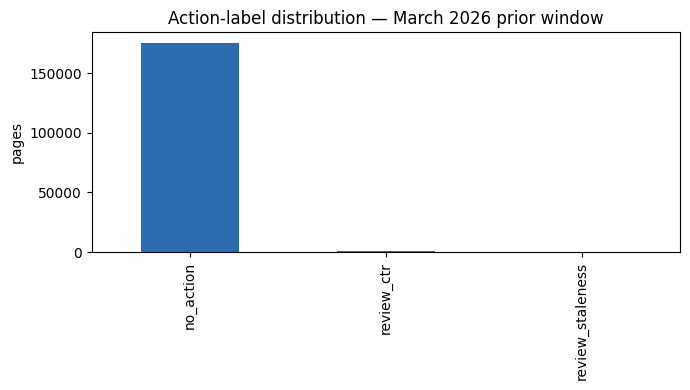

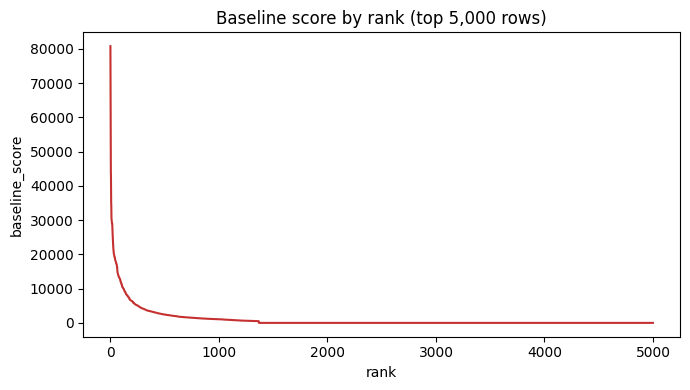


Exported:
  work/outputs/baseline_action_score.csv
  work/outputs/playbook_metrics.json
  work/figures/action_mix.png
  work/figures/score_by_rank.png


In [19]:
# Export 1: ranked queue CSV
queue_out = df[[
    "rank", "content_hash_id", "baseline_score", "reason_code",
    "action_label", "impressions_30d", "clicks_30d", "ctr_30d",
    "avg_position_30d", "days_since_update",
    "content_type", "main_intent"
]]
queue_out.to_csv("work/outputs/baseline_action_score.csv", index=False)
print(f"Wrote work/outputs/baseline_action_score.csv ({len(queue_out):,} rows)")

# Export 2: action-mix figure
fig, ax = plt.subplots(figsize=(7, 4))
df["action_label"].value_counts().plot(kind="bar", ax=ax, color="#2b6cb0")
ax.set_title("Action-label distribution — March 2026 prior window")
ax.set_ylabel("pages")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("work/figures/action_mix.png", dpi=120)
plt.show()

# Export 3: score-by-rank curve (top 5000), shows how quickly the queue drops off
fig, ax = plt.subplots(figsize=(7, 4))
df["baseline_score"].head(5000).plot(ax=ax, color="#c53030")
ax.set_title("Baseline score by rank (top 5,000 rows)")
ax.set_ylabel("baseline_score")
ax.set_xlabel("rank")
plt.tight_layout()
plt.savefig("work/figures/score_by_rank.png", dpi=120)
plt.show()

print()
print("Exported:")
print("  work/outputs/baseline_action_score.csv")
print("  work/outputs/playbook_metrics.json")
print("  work/figures/action_mix.png")
print("  work/figures/score_by_rank.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.